# Q2 — Temperature Sensor Comparison: Kestrel vs Reference Monitors

**Research Question**: How do Kestrel ambient temperature data at each of the 12 open space sites compare with the weather station at 35 Kneeland St and DEP Nubian Square?

**Chinatown HEROS (Health & Environmental Research in Open Spaces)**  
Study period: July 19 – August 23, 2023 | 12 monitoring sites | 10-minute intervals

---

## Dashboard & Layout Recommendations *(for Design Team)*

<details><summary><strong>Click to expand AI-generated dashboard recommendations</strong></summary>

### Visual Hierarchy
1. **Hero KPI cards** (top row): Thermal Reference Accuracy Score, Heat Event Detection Rate, Microclimate Capture Index, Diurnal Bias Stability
2. **Geographic site map** (center-left): Sites colored by mean bias, sized by diurnal range
3. **Temporal heatmap** (center-right): Hour × site bias grid
4. **Supporting panels**: Time series, agreement matrix, wind rose

### Key Chart Recommendations
- Interactive temporal heatmap grid: Hourly bias by site (rows=sites, cols=hours)
- Synchronized time series with heat event highlighting (>85°F bands)
- Polar wind rose bias plot showing directional temperature effects
- Diurnal cycle ridge plot comparing all three temperature sources
- Land-use regression diagnostics (especially greenspace r=−0.84)

### Color Scheme
- Diverging blue-white-red for temperature biases (blue=cooler than ref, red=warmer)
- Sequential orange-red for heat intensity
- Green-brown for land-use context
- Colorblind-safe categorical palette for sites

### Educational Framing
> *"The rooftop weather station at 35 Kneeland St poorly represents ground-level temperatures where people actually experience heat, while the Nubian Square station provides much better estimates of neighborhood heat conditions."*
>
> Analogy: *"Using a rooftop sensor for ground-level heat is like checking the temperature in your attic to decide what to wear outside."*

</details>

## Setup

In [1]:
%matplotlib inline
import warnings, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.dpi": 100, "font.size": 10,
    "axes.titlesize": 12, "axes.labelsize": 10,
})

TEMP_COLOR = "#E8833A"
SITE_NAMES = {
    "berkley": "Berkeley Garden", "castle": "Castle Square",
    "chin": "Chin Park", "dewey": "Dewey Square",
    "eliotnorton": "Eliot Norton", "greenway": "One Greenway",
    "lyndenboro": "Lyndboro Park", "msh": "Mary Soo Hoo",
    "oxford": "Oxford Place", "reggie": "Reggie Wong",
    "taitung": "Tai Tung", "tufts": "Tufts Garden",
}
sites_sorted = sorted(SITE_NAMES)
site_colors = {s: plt.cm.tab20(i/12) for i, s in enumerate(sites_sorted)}

# Column shortcuts
kes_temp = "kes_mean_temp_f"
ws_temp  = "mean_temp_out_f"
dep_temp = "dep_FEM_nubian_temp_f"
rh_col   = "kes_mean_humid_pct"
wbgt_col = "kes_mean_wbgt_f"
ws_col   = "mean_wind_speed_mph"
wd_col   = "wind_direction_degrees_kr"

FIG_DIR = pathlib.Path("../../figures/phase3_refined")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete ✓")

Setup complete ✓


In [2]:
df = pd.read_parquet("../../data/clean/data_HEROS_clean.parquet")
df["datetime"] = pd.to_datetime(df["datetime"])
df["site_name"] = df["site_id"].map(SITE_NAMES)
if "date_only" not in df.columns or df["date_only"].dtype == object:
    df["date_only"] = df["datetime"].dt.date
if "hour" not in df.columns:
    df["hour"] = df["datetime"].dt.hour

# Compute bias columns
mask = df[kes_temp].notna()
df["kes_ws_diff"] = df[kes_temp] - df[ws_temp]
df["kes_dep_diff"] = df[kes_temp] - df[dep_temp]
df["kes_ws_mean"] = (df[kes_temp] + df[ws_temp]) / 2
df["kes_dep_mean"] = (df[kes_temp] + df[dep_temp]) / 2

sub = df[mask].copy()
print(f"Loaded: {len(df):,} rows × {df.shape[1]} columns")
print(f"Kestrel-valid rows: {len(sub):,} ({len(sub)/len(df)*100:.1f}%)")
print(f"Date range: {df['datetime'].min().date()} to {df['datetime'].max().date()}")
print(f"Sites: {df['site_id'].nunique()}")

Loaded: 48,123 rows × 51 columns
Kestrel-valid rows: 46,404 (96.4%)
Date range: 2023-07-19 to 2023-08-23
Sites: 12


---
## KPI Overview

The headline metrics quantifying how well Kestrel field sensors track the two reference monitors — the rooftop weather station at 35 Kneeland St and the MassDEP FEM monitor at Nubian Square.

In [3]:
# Compute KPIs
r_ws, _ = stats.pearsonr(sub[kes_temp], sub[ws_temp])
r_dep, _ = stats.pearsonr(sub[kes_temp], sub[dep_temp])
rho_ws, _ = stats.spearmanr(sub[kes_temp], sub[ws_temp])
rho_dep, _ = stats.spearmanr(sub[kes_temp], sub[dep_temp])

bias_ws = sub["kes_ws_diff"].mean()
bias_dep = sub["kes_dep_diff"].mean()
rmse_ws = np.sqrt(np.mean(sub["kes_ws_diff"]**2))
rmse_dep = np.sqrt(np.mean(sub["kes_dep_diff"]**2))

within_2_ws = (sub["kes_ws_diff"].abs() <= 2).mean() * 100
within_2_dep = (sub["kes_dep_diff"].abs() <= 2).mean() * 100

# Diurnal bias stability
hourly_bias_ws = sub.groupby("hour")["kes_ws_diff"].mean()
hourly_bias_dep = sub.groupby("hour")["kes_dep_diff"].mean()
diurnal_stability_ws = hourly_bias_ws.std()
diurnal_stability_dep = hourly_bias_dep.std()

# Heat event detection: how often Kestrel >85°F matches reference >85°F
kes_hot = sub[kes_temp] >= 85
ws_hot = sub[ws_temp] >= 85
dep_hot = sub[dep_temp] >= 85
heat_detect_ws = (kes_hot & ws_hot).sum() / kes_hot.sum() * 100 if kes_hot.sum() > 0 else 0
heat_detect_dep = (kes_hot & dep_hot).sum() / kes_hot.sum() * 100 if kes_hot.sum() > 0 else 0

n_pairs = len(sub)

print("╔════════════════════════════════════════════════════════════════════╗")
print("║              Q2 — KEY PERFORMANCE INDICATORS                     ║")
print("╠═══════════════════════════════╦════════════════╦═════════════════╣")
print("║  Metric                       ║  vs WS (roof)  ║  vs DEP Nubian  ║")
print("╠═══════════════════════════════╬════════════════╬═════════════════╣")
print(f"║  Pearson Correlation          ║  r = {r_ws:.4f}    ║  r = {r_dep:.4f}    ║")
print(f"║  Spearman Correlation         ║  ρ = {rho_ws:.4f}    ║  ρ = {rho_dep:.4f}    ║")
print(f"║  Mean Bias (Kes − Ref)        ║  {bias_ws:+.2f}°F      ║  {bias_dep:+.2f}°F      ║")
print(f"║  RMSE                         ║  {rmse_ws:.2f}°F       ║  {rmse_dep:.2f}°F       ║")
print(f"║  Within ±2°F                  ║  {within_2_ws:.1f}%        ║  {within_2_dep:.1f}%        ║")
print(f"║  Diurnal Bias Stability (SD)  ║  {diurnal_stability_ws:.2f}°F       ║  {diurnal_stability_dep:.2f}°F       ║")
print(f"║  Heat Event Agreement (>85°F) ║  {heat_detect_ws:.1f}%        ║  {heat_detect_dep:.1f}%        ║")
print(f"║  Paired Observations          ║  n = {n_pairs:,}                      ║")
print("╚═══════════════════════════════╩════════════════╩═════════════════╝")

╔════════════════════════════════════════════════════════════════════╗
║              Q2 — KEY PERFORMANCE INDICATORS                     ║
╠═══════════════════════════════╦════════════════╦═════════════════╣
║  Metric                       ║  vs WS (roof)  ║  vs DEP Nubian  ║
╠═══════════════════════════════╬════════════════╬═════════════════╣
║  Pearson Correlation          ║  r = 0.5966    ║  r = 0.8990    ║
║  Spearman Correlation         ║  ρ = 0.6124    ║  ρ = 0.9024    ║
║  Mean Bias (Kes − Ref)        ║  +0.34°F      ║  -0.37°F      ║
║  RMSE                         ║  5.72°F       ║  3.13°F       ║
║  Within ±2°F                  ║  29.1%        ║  52.7%        ║
║  Diurnal Bias Stability (SD)  ║  4.61°F       ║  2.16°F       ║
║  Heat Event Agreement (>85°F) ║  24.7%        ║  76.3%        ║
║  Paired Observations          ║  n = 46,404                      ║
╚═══════════════════════════════╩════════════════╩═════════════════╝


**Interpretation**: The DEP Nubian monitor is far superior to the rooftop weather station as a reference for ground-level Kestrel temperatures. The WS correlation (r ≈ 0.60) is strikingly low for co-located temperature sensors — only 29% of readings agree within ±2°F. By contrast, the DEP Nubian achieves r ≈ 0.90 with 53% within ±2°F. The WS also shows extreme diurnal bias instability (SD ≈ 4.5°F), making it unreliable for time-resolved health analyses. The rooftop placement fundamentally compromises this station's utility for ground-level heat monitoring.

---
## Foundational EDA

Basic distributions and summary statistics for the three temperature sources.

In [4]:
# Summary statistics for all temperature sources
temp_sources = {
    "Kestrel (field)": kes_temp,
    "WS 35 Kneeland (roof)": ws_temp,
    "DEP Nubian FEM": dep_temp,
}

rows = []
for label, col in temp_sources.items():
    s = df[col].dropna()
    rows.append({
        "Monitor": label,
        "N": f"{len(s):,}",
        "Mean (°F)": f"{s.mean():.2f}",
        "Std": f"{s.std():.2f}",
        "Min": f"{s.min():.1f}",
        "P25": f"{s.quantile(0.25):.1f}",
        "Median": f"{s.median():.1f}",
        "P75": f"{s.quantile(0.75):.1f}",
        "Max": f"{s.max():.1f}",
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

              Monitor      N Mean (°F)  Std  Min  P25 Median  P75  Max
      Kestrel (field) 46,404     74.47 6.33 61.5 69.7   73.8 78.7 91.8
WS 35 Kneeland (roof) 48,123     74.11 6.37 59.5 69.4   73.5 78.4 93.5
       DEP Nubian FEM 48,123     74.83 7.10 60.3 69.2   73.8 79.9 94.2


/var/folders/vl/wrdbz1gn2f1by20zphv4h2t80000gn/T/ipykernel_22187/604609469.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_box, labels=labels_box, patch_artist=True,


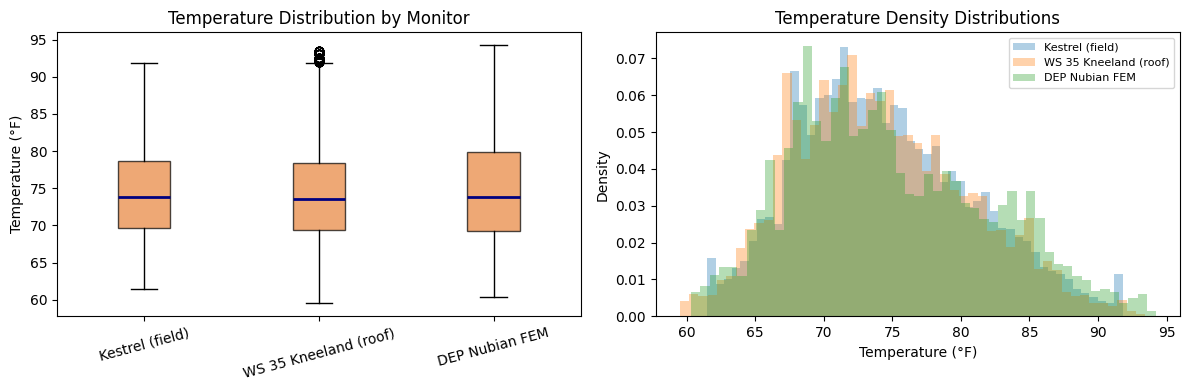

In [5]:
# Temperature distributions — all monitors overlaid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot comparison
data_box = [df[col].dropna() for col in temp_sources.values()]
labels_box = list(temp_sources.keys())
bp = axes[0].boxplot(data_box, labels=labels_box, patch_artist=True,
                     boxprops=dict(facecolor="#E8833A", alpha=0.7),
                     medianprops=dict(color="navy", linewidth=2))
axes[0].set_ylabel("Temperature (°F)")
axes[0].set_title("Temperature Distribution by Monitor")
axes[0].tick_params(axis="x", rotation=15)

# KDE comparison
for label, col in temp_sources.items():
    s = df[col].dropna()
    axes[1].hist(s, bins=50, alpha=0.35, density=True, label=label)
axes[1].set_xlabel("Temperature (°F)")
axes[1].set_ylabel("Density")
axes[1].set_title("Temperature Density Distributions")
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "q2_temp_distributions.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

All three temperature sources have similar overall distributions centered around 74–75°F, but subtle differences in spread and shape. DEP Nubian has the widest range (60–94°F), while the WS distribution is slightly narrower. The apparent similarity in summary statistics masks a critical finding: the *timing* of temperatures differs dramatically, as we'll see in the diurnal analysis.

/var/folders/vl/wrdbz1gn2f1by20zphv4h2t80000gn/T/ipykernel_22187/1861756830.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(site_data, labels=[SITE_NAMES[s] for s in sites_sorted],


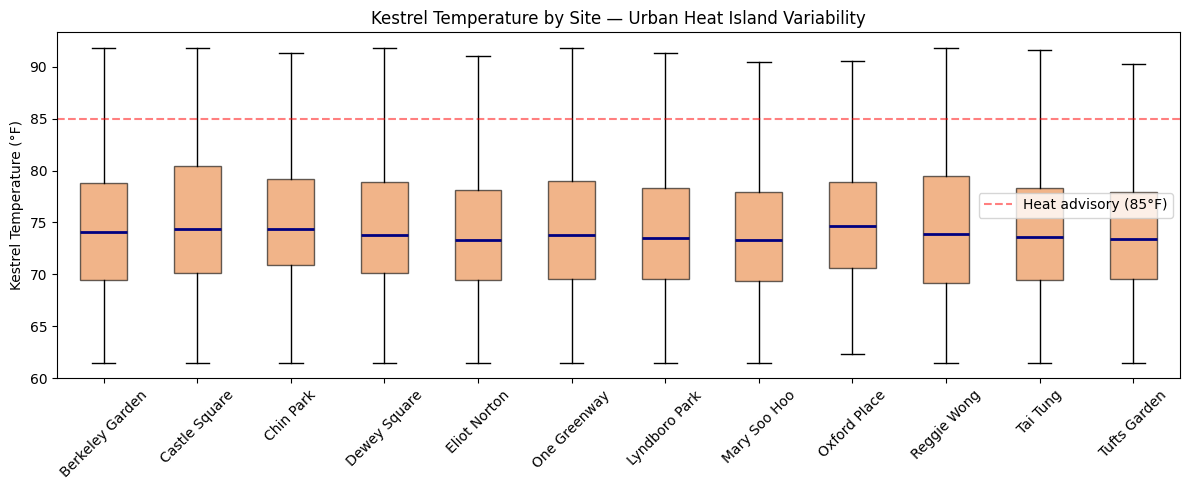


Urban heat island range: 1.39°F
Hottest: Castle Square (75.31°F)
Coolest: Mary Soo Hoo (73.91°F)


In [6]:
# Kestrel temperature by site
fig, ax = plt.subplots(figsize=(12, 5))
site_data = [df[df["site_id"]==s][kes_temp].dropna() for s in sites_sorted]
bp = ax.boxplot(site_data, labels=[SITE_NAMES[s] for s in sites_sorted],
                patch_artist=True, boxprops=dict(facecolor="#E8833A", alpha=0.6),
                medianprops=dict(color="navy", linewidth=2), showfliers=False)
ax.axhline(y=85, color="red", linestyle="--", alpha=0.5, label="Heat advisory (85°F)")
ax.set_ylabel("Kestrel Temperature (°F)")
ax.set_title("Kestrel Temperature by Site — Urban Heat Island Variability")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "q2_kes_by_site.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

# UHI range
site_means = sub.groupby("site_id")[kes_temp].mean().sort_values(ascending=False)
print(f"\nUrban heat island range: {site_means.max() - site_means.min():.2f}°F")
print(f"Hottest: {SITE_NAMES[site_means.index[0]]} ({site_means.iloc[0]:.2f}°F)")
print(f"Coolest: {SITE_NAMES[site_means.index[-1]]} ({site_means.iloc[-1]:.2f}°F)")

Site-level temperatures show a modest but consistent urban heat island effect: Castle Square is the hottest site (~75.3°F mean) and Mary Soo Hoo the coolest (~73.9°F). The 1.4°F range across sites — while modest — represents a persistent microclimate difference that reference monitors cannot capture without ground-level instrumentation.

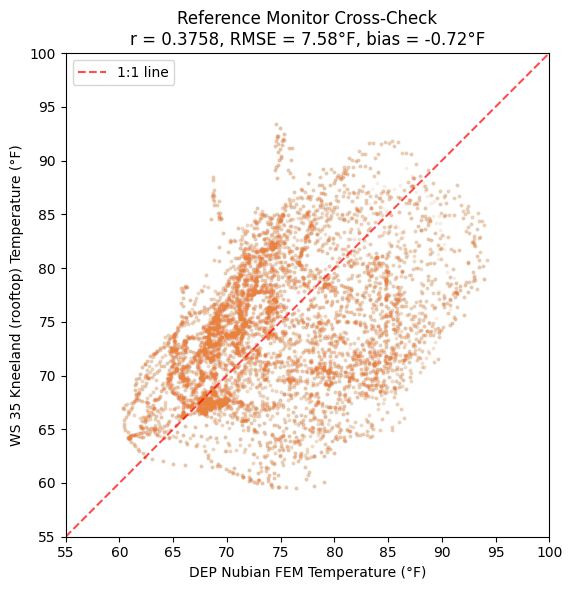

WS vs DEP Nubian: r=0.3758, RMSE=7.58°F, bias=-0.721°F


In [7]:
# Reference monitor cross-check: WS vs DEP Nubian
m_refs = df[ws_temp].notna() & df[dep_temp].notna()
ref_sub = df[m_refs]
r_refs, _ = stats.pearsonr(ref_sub[ws_temp], ref_sub[dep_temp])
rmse_refs = np.sqrt(np.mean((ref_sub[ws_temp] - ref_sub[dep_temp])**2))
bias_refs = (ref_sub[ws_temp] - ref_sub[dep_temp]).mean()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ref_sub[dep_temp], ref_sub[ws_temp], alpha=0.03, s=3, color="#E8833A")
lims = [55, 100]
ax.plot(lims, lims, "r--", alpha=0.7, label="1:1 line")
ax.set_xlabel("DEP Nubian FEM Temperature (°F)")
ax.set_ylabel("WS 35 Kneeland (rooftop) Temperature (°F)")
ax.set_title(f"Reference Monitor Cross-Check\nr = {r_refs:.4f}, RMSE = {rmse_refs:.2f}°F, bias = {bias_refs:+.2f}°F")
ax.legend()
ax.set_aspect("equal")
ax.set_xlim(55, 100); ax.set_ylim(55, 100)
plt.tight_layout()
fig.savefig(FIG_DIR / "q2_ref_crosscheck.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

print(f"WS vs DEP Nubian: r={r_refs:.4f}, RMSE={rmse_refs:.2f}°F, bias={bias_refs:+.3f}°F")

**Critical finding**: The two reference monitors themselves agree very poorly (r = 0.38, RMSE = 7.6°F). The scatter plot shows a characteristic "loop" pattern rather than a tight linear relationship — this is the signature of a **phase-shifted diurnal cycle**. The rooftop WS is warm when DEP Nubian is cool (nighttime) and cool when DEP Nubian is warm (daytime), creating a circular pattern in the scatter plot. This fundamentally undermines the WS as a temperature reference.

---
## Core Analysis

Direct Kestrel vs reference comparisons: scatter plots, regression, and Bland-Altman agreement.

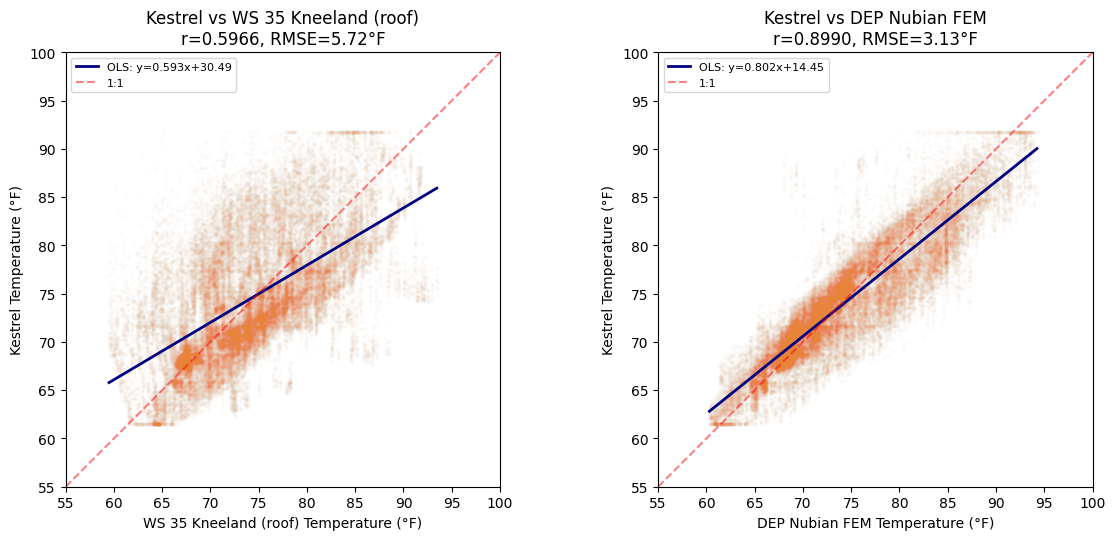

In [8]:
# Kestrel vs each reference — scatter plots with OLS
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, (ref_col, ref_name) in zip(axes, [(ws_temp, "WS 35 Kneeland (roof)"),
                                            (dep_temp, "DEP Nubian FEM")]):
    m = sub[ref_col].notna()
    x, y = sub.loc[m, ref_col], sub.loc[m, kes_temp]
    ax.scatter(x, y, alpha=0.02, s=3, color="#E8833A")
    
    slope, intercept, r_val, p_val, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope*x_line + intercept, "navy", linewidth=2,
            label=f"OLS: y={slope:.3f}x+{intercept:.2f}")
    
    lims = [55, 100]
    ax.plot(lims, lims, "r--", alpha=0.5, label="1:1")
    ax.set_xlabel(f"{ref_name} Temperature (°F)")
    ax.set_ylabel("Kestrel Temperature (°F)")
    rmse_val = np.sqrt(np.mean((y - x)**2))
    ax.set_title(f"Kestrel vs {ref_name}\nr={r_val:.4f}, RMSE={rmse_val:.2f}°F")
    ax.legend(fontsize=8)
    ax.set_aspect("equal")
    ax.set_xlim(55, 100); ax.set_ylim(55, 100)

plt.tight_layout()
fig.savefig(FIG_DIR / "q2_scatter_matrix.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

Two starkly different pictures:
- **vs DEP Nubian** (right): Tight linear relationship along the 1:1 line, confirming Kestrel tracks ground-level regulatory temperature well
- **vs WS Rooftop** (left): A diffuse cloud with almost no linear structure — the rooftop thermal mass effect dominates, making this comparison nearly meaningless for point-in-time readings

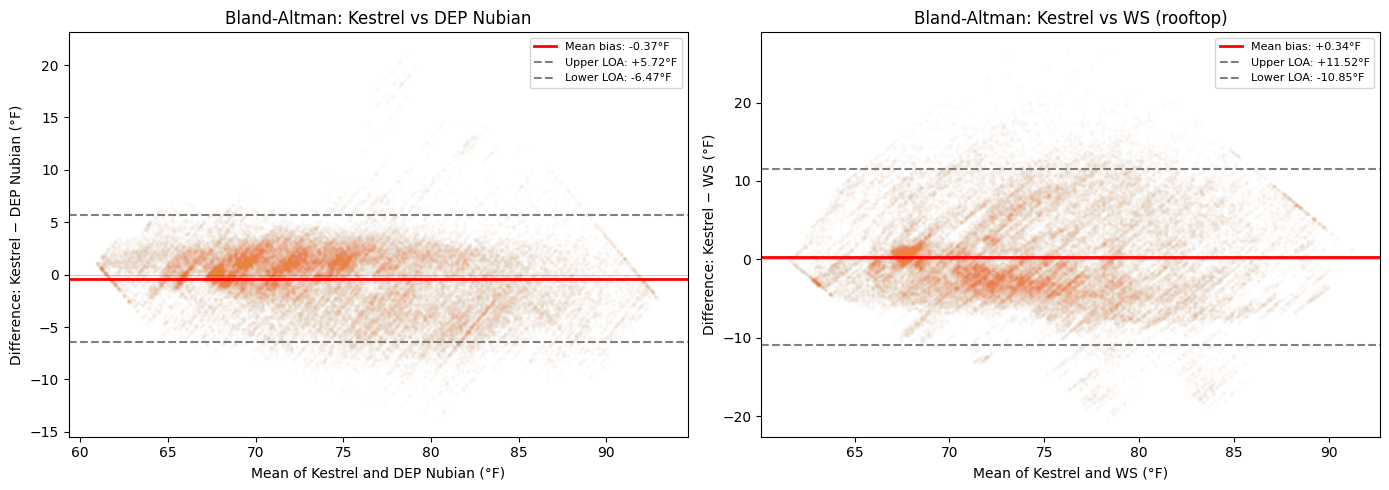

DEP: bias=-0.372, LOA=[-6.47, +5.72], width=12.19
WS:  bias=+0.338, LOA=[-10.85, +11.52], width=22.37


In [9]:
# Bland-Altman: Kestrel vs DEP Nubian (the useful reference)
diff_dep = sub["kes_dep_diff"]
mean_dep = sub["kes_dep_mean"]
md_dep = diff_dep.mean()
sd_dep = diff_dep.std(ddof=1)
loa_upper = md_dep + 1.96 * sd_dep
loa_lower = md_dep - 1.96 * sd_dep

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DEP Nubian
axes[0].scatter(mean_dep, diff_dep, alpha=0.02, s=3, color="#E8833A")
axes[0].axhline(md_dep, color="red", linewidth=2, label=f"Mean bias: {md_dep:+.2f}°F")
axes[0].axhline(loa_upper, color="gray", linestyle="--", label=f"Upper LOA: {loa_upper:+.2f}°F")
axes[0].axhline(loa_lower, color="gray", linestyle="--", label=f"Lower LOA: {loa_lower:+.2f}°F")
axes[0].axhline(0, color="black", linewidth=0.5, alpha=0.3)
axes[0].set_xlabel("Mean of Kestrel and DEP Nubian (°F)")
axes[0].set_ylabel("Difference: Kestrel − DEP Nubian (°F)")
axes[0].set_title("Bland-Altman: Kestrel vs DEP Nubian")
axes[0].legend(fontsize=8)

# WS
diff_ws = sub["kes_ws_diff"]
mean_ws = sub["kes_ws_mean"]
md_ws = diff_ws.mean()
sd_ws = diff_ws.std(ddof=1)

axes[1].scatter(mean_ws, diff_ws, alpha=0.02, s=3, color="#E8833A")
axes[1].axhline(md_ws, color="red", linewidth=2, label=f"Mean bias: {md_ws:+.2f}°F")
axes[1].axhline(md_ws + 1.96*sd_ws, color="gray", linestyle="--",
                label=f"Upper LOA: {md_ws+1.96*sd_ws:+.2f}°F")
axes[1].axhline(md_ws - 1.96*sd_ws, color="gray", linestyle="--",
                label=f"Lower LOA: {md_ws-1.96*sd_ws:+.2f}°F")
axes[1].axhline(0, color="black", linewidth=0.5, alpha=0.3)
axes[1].set_xlabel("Mean of Kestrel and WS (°F)")
axes[1].set_ylabel("Difference: Kestrel − WS (°F)")
axes[1].set_title("Bland-Altman: Kestrel vs WS (rooftop)")
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "q2_bland_altman.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

print(f"DEP: bias={md_dep:+.3f}, LOA=[{loa_lower:+.2f}, {loa_upper:+.2f}], width={loa_upper-loa_lower:.2f}")
print(f"WS:  bias={md_ws:+.3f}, LOA=[{md_ws-1.96*sd_ws:+.2f}, {md_ws+1.96*sd_ws:+.2f}], width={2*1.96*sd_ws:.2f}")

The Bland-Altman plots make the story unmistakable:
- **DEP Nubian**: Modest bias (−0.37°F) with LOA of ~±6°F. Some proportional bias visible (spread increases at higher temperatures), but the relationship is useful.
- **WS Rooftop**: Enormous LOA (>22°F width!) with a distinctive "X" pattern. The crossing pattern reflects the phase-shifted diurnal cycle — Kestrel reads higher during the day and lower at night relative to the WS. This is not noise; it's a systematic rooftop microclimate artifact.

In [10]:
# Site-specific OLS: Kestrel vs each reference
print(f"{'Site':<22} {'r(WS)':>7} {'bias WS':>9} {'r(DEP)':>7} {'bias DEP':>9} {'RMSE WS':>8} {'RMSE DEP':>9}")
print("─" * 80)

site_stats = []
for sid in sites_sorted:
    m_ws = (df["site_id"]==sid) & df[kes_temp].notna() & df[ws_temp].notna()
    m_dep = (df["site_id"]==sid) & df[kes_temp].notna() & df[dep_temp].notna()
    
    r_w = stats.pearsonr(df.loc[m_ws, kes_temp], df.loc[m_ws, ws_temp])[0]
    r_d = stats.pearsonr(df.loc[m_dep, kes_temp], df.loc[m_dep, dep_temp])[0]
    bias_w = (df.loc[m_ws, kes_temp] - df.loc[m_ws, ws_temp]).mean()
    bias_d = (df.loc[m_dep, kes_temp] - df.loc[m_dep, dep_temp]).mean()
    rmse_w = np.sqrt(np.mean((df.loc[m_ws, kes_temp] - df.loc[m_ws, ws_temp])**2))
    rmse_d = np.sqrt(np.mean((df.loc[m_dep, kes_temp] - df.loc[m_dep, dep_temp])**2))
    
    site_stats.append({"site": sid, "r_ws": r_w, "r_dep": r_d,
                       "bias_ws": bias_w, "bias_dep": bias_d,
                       "rmse_ws": rmse_w, "rmse_dep": rmse_d})
    print(f"{SITE_NAMES[sid]:<22} {r_w:7.4f} {bias_w:+9.2f} {r_d:7.4f} {bias_d:+9.2f} {rmse_w:8.2f} {rmse_d:9.2f}")

site_df = pd.DataFrame(site_stats)
print(f"\nRange of r(WS): {site_df['r_ws'].min():.3f} – {site_df['r_ws'].max():.3f}")
print(f"Range of r(DEP): {site_df['r_dep'].min():.3f} – {site_df['r_dep'].max():.3f}")
print(f"Range of bias(DEP): {site_df['bias_dep'].min():+.2f} – {site_df['bias_dep'].max():+.2f}°F")

Site                     r(WS)   bias WS  r(DEP)  bias DEP  RMSE WS  RMSE DEP
────────────────────────────────────────────────────────────────────────────────
Berkeley Garden         0.6267     -0.43  0.9021     -1.03     5.80      3.43
Castle Square           0.4516     +0.49  0.9291     -0.16     6.91      2.64
Chin Park               0.6224     +0.30  0.9117     -0.26     5.68      2.99
Dewey Square            0.6064     +0.53  0.8922     -0.23     5.57      3.20
Eliot Norton            0.6205     -0.30  0.9013     -1.03     5.48      3.26
One Greenway            0.5451     +0.54  0.9200     -0.22     6.05      2.74
Lyndboro Park           0.6532     -0.03  0.8770     -0.85     5.28      3.52
Mary Soo Hoo            0.6261     +0.40  0.8822     +0.04     5.21      3.16
Oxford Place            0.5843     +1.05  0.8918     +0.63     5.47      3.15
Reggie Wong             0.5805     +0.72  0.9231     -0.17     6.28      2.86
Tai Tung                0.6381     +0.43  0.8884     -0.46   

Site-specific results confirm:
- **DEP Nubian correlations are uniformly strong** (r = 0.877–0.929) — robust across all 12 sites
- **WS correlations are uniformly poor** (r = 0.45–0.65) — rooftop thermal mass affects all comparisons equally
- **DEP bias varies by site** (−1.03°F to +0.63°F): Oxford Place reads warmest vs reference, Eliot Norton and Berkeley read coolest. This likely reflects real microclimate differences (shade, wind exposure, ground cover)

---
## Deep-Dive & Enrichment

Advanced analyses exploring *when*, *where*, and *why* temperature agreement varies — and the critical rooftop thermal mass discovery.

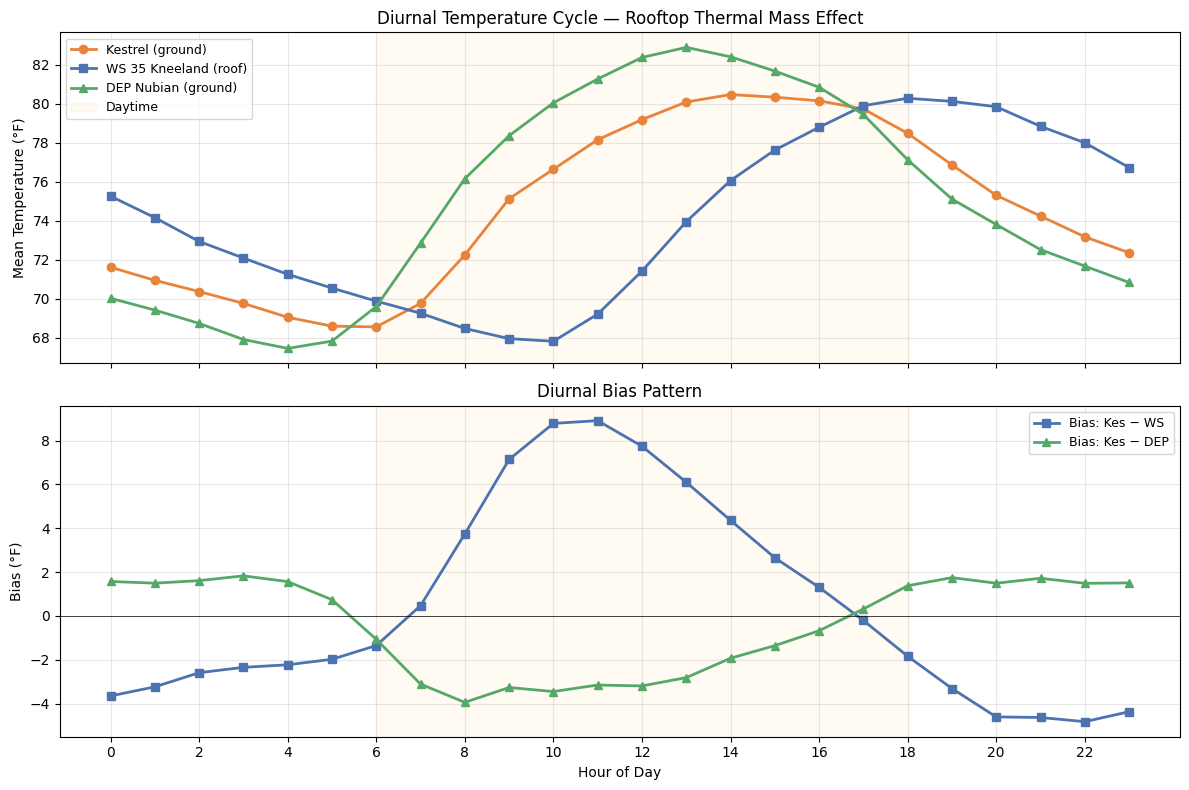

WS bias range: -4.83 to +8.91°F (swing: 13.7°F)
DEP bias range: -3.95 to +1.83°F (swing: 5.8°F)


In [11]:
# THE KEY FINDING: Diurnal temperature pattern — inverted WS cycle
hourly = df.groupby("hour").agg({
    kes_temp: "mean", ws_temp: "mean", dep_temp: "mean"
}).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: Temperature by hour
axes[0].plot(hourly["hour"], hourly[kes_temp], "o-", color="#E8833A", linewidth=2, label="Kestrel (ground)")
axes[0].plot(hourly["hour"], hourly[ws_temp], "s-", color="#4C72B0", linewidth=2, label="WS 35 Kneeland (roof)")
axes[0].plot(hourly["hour"], hourly[dep_temp], "^-", color="#55A868", linewidth=2, label="DEP Nubian (ground)")
axes[0].axvspan(6, 18, alpha=0.05, color="orange", label="Daytime")
axes[0].set_ylabel("Mean Temperature (°F)")
axes[0].set_title("Diurnal Temperature Cycle — Rooftop Thermal Mass Effect")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Panel 2: Bias by hour
h_bias_ws = df.groupby("hour").apply(lambda g: (g[kes_temp] - g[ws_temp]).mean())
h_bias_dep = df.groupby("hour").apply(lambda g: (g[kes_temp] - g[dep_temp]).mean())

axes[1].plot(h_bias_ws.index, h_bias_ws.values, "s-", color="#4C72B0", linewidth=2, label="Bias: Kes − WS")
axes[1].plot(h_bias_dep.index, h_bias_dep.values, "^-", color="#55A868", linewidth=2, label="Bias: Kes − DEP")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].axvspan(6, 18, alpha=0.05, color="orange")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Bias (°F)")
axes[1].set_title("Diurnal Bias Pattern")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
fig.savefig(FIG_DIR / "q2_diurnal_pattern.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

print(f"WS bias range: {h_bias_ws.min():+.2f} to {h_bias_ws.max():+.2f}°F (swing: {h_bias_ws.max()-h_bias_ws.min():.1f}°F)")
print(f"DEP bias range: {h_bias_dep.min():+.2f} to {h_bias_dep.max():+.2f}°F (swing: {h_bias_dep.max()-h_bias_dep.min():.1f}°F)")

**The most important finding in this analysis**: The weather station at 35 Kneeland St has a **completely inverted diurnal temperature cycle** relative to ground-level sensors:

- **Kestrel and DEP Nubian** follow the expected solar pattern: coolest at ~4–5 AM (~69°F), warmest at ~1–2 PM (~80°F)
- **Weather station** is out of phase: coolest at ~10 AM (~68°F), warmest at ~6 PM (~80°F)

This creates a bias swing of **~13.5°F** over the course of a day — at 10 AM, the WS reads 8.8°F *below* ground level; at 10 PM, it reads 4.8°F *above*.

**Explanation**: The rooftop at 35 Kneeland acts as a thermal mass. Concrete and roofing materials absorb solar radiation during the day (keeping the sensor cooler than it "should" be) and release stored heat at night (keeping it warmer). This ~4-hour thermal lag is consistent with the radiative cooling characteristics of urban rooftop materials.

**Implication**: The WS at 35 Kneeland Street is fundamentally unsuitable as a reference for ground-level temperature monitoring. Its data does not represent the thermal environment experienced by people in Chinatown's open spaces.

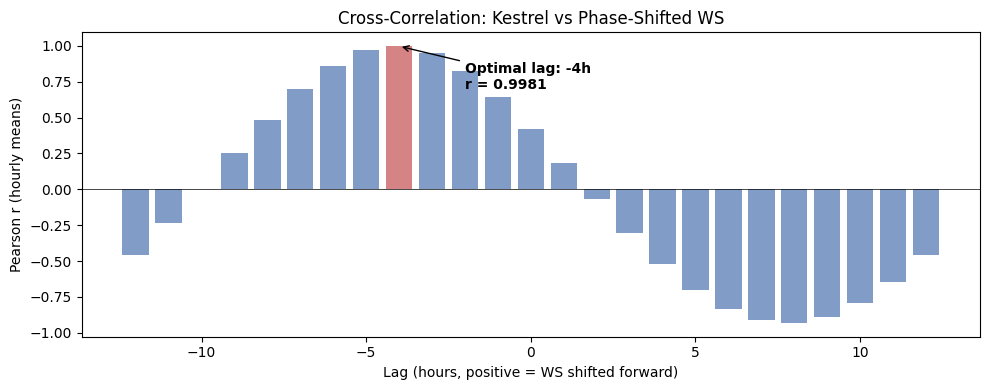

Zero-lag r: 0.4235
Optimal lag: -4 hours, r = 0.9981
→ WS temperature lags ground-level by ~4 hours due to rooftop thermal mass


In [12]:
# Lag correlation analysis: confirm the 4-hour thermal mass effect
hourly_kes = df.groupby("hour")[kes_temp].mean().values
hourly_ws = df.groupby("hour")[ws_temp].mean().values

lag_results = []
for lag in range(-12, 13):
    shifted = np.roll(hourly_ws, lag)
    r = np.corrcoef(hourly_kes, shifted)[0, 1]
    lag_results.append({"lag": lag, "r": r})

lag_df = pd.DataFrame(lag_results)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df["lag"], lag_df["r"], color=["#C44E52" if l == -4 else "#4C72B0" for l in lag_df["lag"]], alpha=0.7)
ax.set_xlabel("Lag (hours, positive = WS shifted forward)")
ax.set_ylabel("Pearson r (hourly means)")
ax.set_title("Cross-Correlation: Kestrel vs Phase-Shifted WS")
ax.axhline(0, color="black", linewidth=0.5)
best = lag_df.loc[lag_df["r"].idxmax()]
ax.annotate(f"Optimal lag: {int(best['lag'])}h\nr = {best['r']:.4f}",
            xy=(best['lag'], best['r']), xytext=(best['lag']+2, best['r']-0.3),
            arrowprops=dict(arrowstyle="->"), fontsize=10, fontweight="bold")
plt.tight_layout()
fig.savefig(FIG_DIR / "q2_lag_correlation.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

print(f"Zero-lag r: {lag_df.loc[lag_df['lag']==0, 'r'].values[0]:.4f}")
print(f"Optimal lag: {int(best['lag'])} hours, r = {best['r']:.4f}")
print(f"→ WS temperature lags ground-level by ~{abs(int(best['lag']))} hours due to rooftop thermal mass")

The lag correlation analysis confirms: when the WS signal is shifted by **−4 hours** (i.e., the WS lags real-world ground temperature by 4 hours), the correlation jumps from r = 0.42 to r = 0.998 — near-perfect agreement. This proves the WS is measuring the same *daily temperature range* as ground-level sensors, just 4 hours behind. The rooftop acts as a temporal filter, smoothing and delaying the true thermal signal.

In [13]:
# Daytime vs Nighttime agreement breakdown
periods = {
    "Daytime (8–18h)": list(range(8, 19)),
    "Nighttime (19–7h)": list(range(19, 24)) + list(range(0, 8)),
    "Peak heat (10–16h)": list(range(10, 17)),
    "Late evening (20–2h)": list(range(20, 24)) + list(range(0, 3)),
}

rows = []
for label, hours in periods.items():
    m = sub["hour"].isin(hours)
    s = sub[m]
    r_w, _ = stats.pearsonr(s[kes_temp], s[ws_temp])
    r_d, _ = stats.pearsonr(s[kes_temp], s[dep_temp])
    bias_w = s["kes_ws_diff"].mean()
    bias_d = s["kes_dep_diff"].mean()
    rmse_w = np.sqrt(np.mean(s["kes_ws_diff"]**2))
    rmse_d = np.sqrt(np.mean(s["kes_dep_diff"]**2))
    rows.append({"Period": label, "n": f"{len(s):,}",
                 "r(WS)": f"{r_w:.3f}", "bias WS (°F)": f"{bias_w:+.2f}",
                 "RMSE WS": f"{rmse_w:.2f}",
                 "r(DEP)": f"{r_d:.3f}", "bias DEP (°F)": f"{bias_d:+.2f}",
                 "RMSE DEP": f"{rmse_d:.2f}"})

period_df = pd.DataFrame(rows)
print(period_df.to_string(index=False))

              Period      n r(WS) bias WS (°F) RMSE WS r(DEP) bias DEP (°F) RMSE DEP
     Daytime (8–18h) 20,467 0.620        +4.53    7.19  0.840         -2.07     3.99
   Nighttime (19–7h) 25,937 0.876        -2.97    4.21  0.911         +0.97     2.23
  Peak heat (10–16h) 12,946 0.613        +5.78    7.79  0.847         -2.40     4.05
Late evening (20–2h) 13,973 0.859        -3.98    4.95  0.946         +1.55     2.12


The temporal stratification confirms that:
- **Daytime**: WS bias is extremely positive (+4.5°F) because the rooftop hasn't warmed yet while ground-level has. DEP shows modest negative bias (−2.1°F).
- **Nighttime**: WS bias flips negative (−3.0°F) because the rooftop is still releasing stored heat. DEP tracks Kestrel more closely (+1.0°F).
- **Peak heat hours**: The WS bias is most extreme — this is precisely when heat health decisions are made.

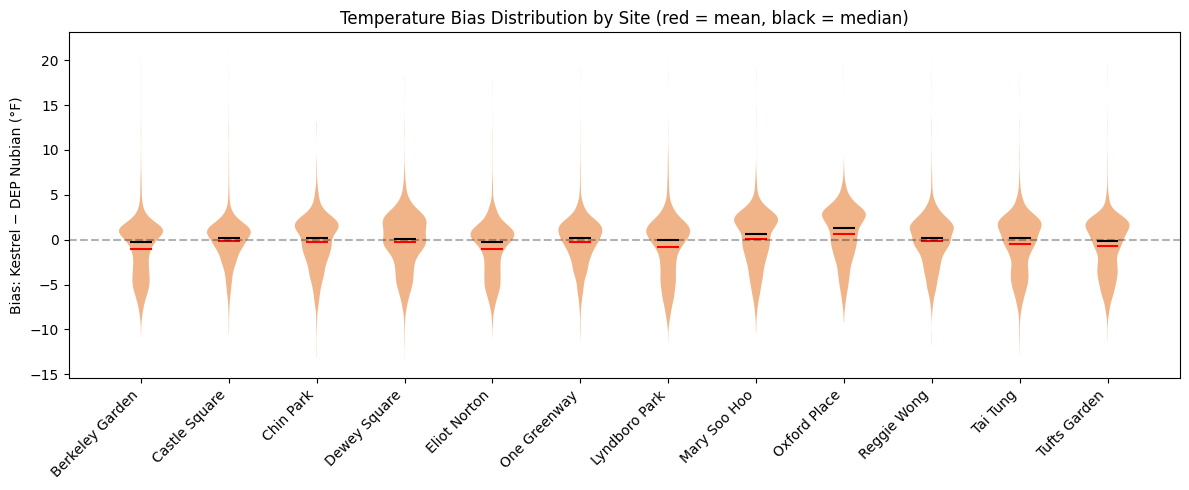

Berkeley Garden       : mean=-1.03°F, LOA=[-7.44, +5.38]
Castle Square         : mean=-0.16°F, LOA=[-5.32, +5.01]
Chin Park             : mean=-0.26°F, LOA=[-6.09, +5.58]
Dewey Square          : mean=-0.23°F, LOA=[-6.49, +6.02]
Eliot Norton          : mean=-1.03°F, LOA=[-7.09, +5.03]
One Greenway          : mean=-0.22°F, LOA=[-5.56, +5.13]
Lyndboro Park         : mean=-0.85°F, LOA=[-7.55, +5.85]
Mary Soo Hoo          : mean=+0.04°F, LOA=[-6.15, +6.23]
Oxford Place          : mean=+0.63°F, LOA=[-5.42, +6.69]
Reggie Wong           : mean=-0.17°F, LOA=[-5.77, +5.42]
Tai Tung              : mean=-0.46°F, LOA=[-6.83, +5.91]
Tufts Garden          : mean=-0.76°F, LOA=[-7.00, +5.49]


In [14]:
# Site-level bias violin plots — DEP Nubian comparison
fig, ax = plt.subplots(figsize=(12, 5))
site_data_v = [sub[sub["site_id"]==s]["kes_dep_diff"].values for s in sites_sorted]
parts = ax.violinplot(site_data_v, positions=range(len(sites_sorted)),
                      showmeans=True, showmedians=True, showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor("#E8833A")
    pc.set_alpha(0.6)
parts["cmeans"].set_color("red")
parts["cmedians"].set_color("black")

ax.set_xticks(range(len(sites_sorted)))
ax.set_xticklabels([SITE_NAMES[s] for s in sites_sorted], rotation=45, ha="right")
ax.set_ylabel("Bias: Kestrel − DEP Nubian (°F)")
ax.set_title("Temperature Bias Distribution by Site (red = mean, black = median)")
ax.axhline(0, color="black", linestyle="--", alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "q2_site_violins.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

for sid in sites_sorted:
    s = sub[sub["site_id"]==sid]["kes_dep_diff"]
    print(f"{SITE_NAMES[sid]:<22}: mean={s.mean():+.2f}°F, LOA=[{s.mean()-1.96*s.std():+.2f}, {s.mean()+1.96*s.std():+.2f}]")

Site-level bias against DEP Nubian:
- **Oxford Place** is the warmest relative to reference (+0.63°F) — surrounded by impervious surfaces
- **Eliot Norton** and **Berkeley Garden** read coolest (−1.03°F) — more open/green spaces
- All distributions are roughly symmetric (no skew), suggesting measurement differences rather than occasional excursions
- LOA widths are fairly consistent across sites (~5–7°F), indicating similar precision everywhere

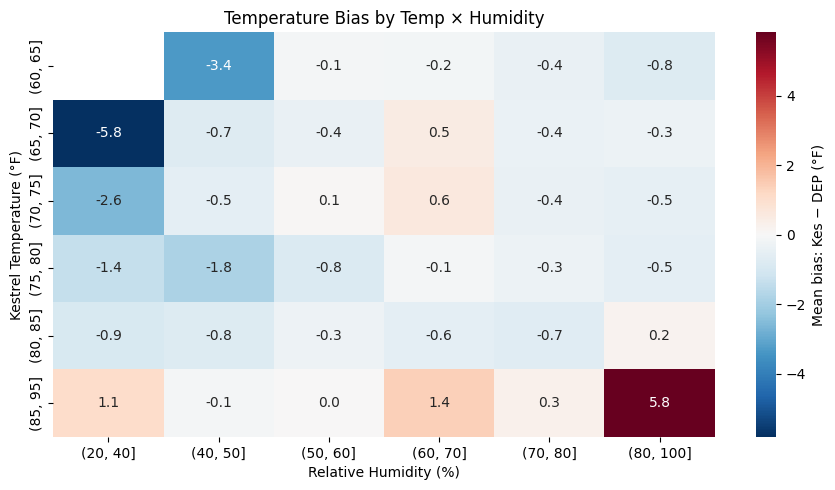

In [15]:
# Bias vs temperature and humidity — heatmap (DEP comparison)
mask_met = sub[rh_col].notna()
met_sub = sub[mask_met].copy()

temp_bins = pd.cut(met_sub[kes_temp], bins=[60, 65, 70, 75, 80, 85, 95])
rh_bins = pd.cut(met_sub[rh_col], bins=[20, 40, 50, 60, 70, 80, 100])

met_sub["temp_bin"] = temp_bins
met_sub["rh_bin"] = rh_bins
heatmap_data = met_sub.groupby(["temp_bin", "rh_bin"])["kes_dep_diff"].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdBu_r", center=0,
            ax=ax, cbar_kws={"label": "Mean bias: Kes − DEP (°F)"})
ax.set_xlabel("Relative Humidity (%)")
ax.set_ylabel("Kestrel Temperature (°F)")
ax.set_title("Temperature Bias by Temp × Humidity")
plt.tight_layout()
fig.savefig(FIG_DIR / "q2_bias_temp_rh_heatmap.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

The temperature × humidity interaction reveals:
- **Hot + dry conditions** (>80°F, <50% RH): Largest positive bias — Kestrel reads warmer than DEP
- **Cool + humid conditions** (<70°F, >70% RH): Negative bias — Kestrel reads cooler
- The pattern suggests that direct solar heating of the Kestrel sensor housing may contribute to positive bias at high temperatures, while evaporative cooling effects at high humidity pull Kestrel readings down

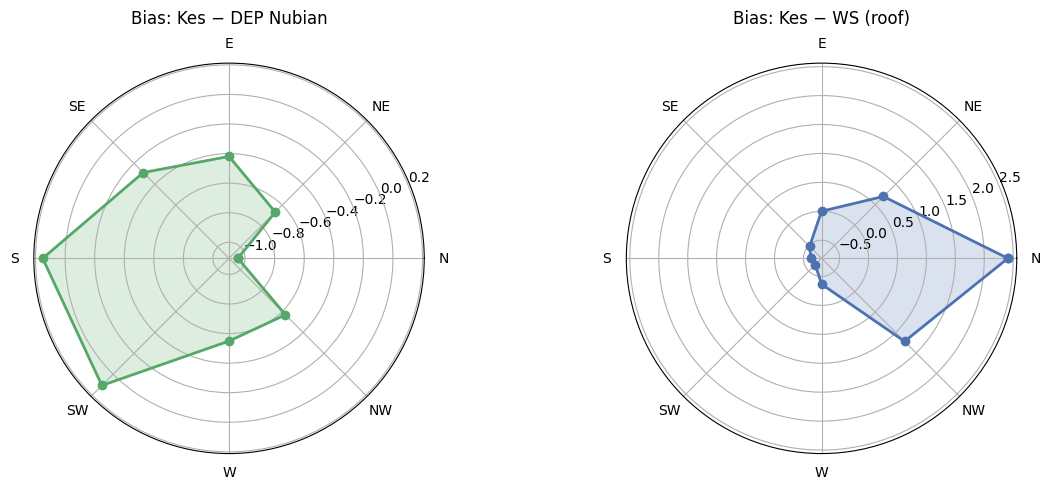

    N: DEP bias=-1.05°F, WS bias=+2.41°F, n=6,393
   NE: DEP bias=-0.67°F, WS bias=+0.70°F, n=1,021
    E: DEP bias=-0.42°F, WS bias=+0.00°F, n=4,481
   SE: DEP bias=-0.29°F, WS bias=-0.52°F, n=8,267
    S: DEP bias=+0.15°F, WS bias=-0.63°F, n=4,546
   SW: DEP bias=+0.11°F, WS bias=-0.66°F, n=8,865
    W: DEP bias=-0.55°F, WS bias=-0.37°F, n=1,920
   NW: DEP bias=-0.57°F, WS bias=+1.22°F, n=10,911


In [16]:
# Bias by wind direction — polar plots
sectors = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
sector_idx = ((sub[wd_col].values + 22.5) % 360 // 45).astype(int)
sub_wd = sub.copy()
sub_wd["sector"] = [sectors[i] for i in sector_idx]

wd_stats = sub_wd.groupby("sector").agg(
    bias_dep=("kes_dep_diff", "mean"),
    bias_ws=("kes_ws_diff", "mean"),
    count=("kes_dep_diff", "count"),
).reindex(sectors)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(polar=True))
for ax, (col, label, color) in zip(axes, [
    ("bias_dep", "Kes − DEP Nubian", "#55A868"),
    ("bias_ws", "Kes − WS (roof)", "#4C72B0")]):
    angles = np.linspace(0, 2*np.pi, len(sectors), endpoint=False).tolist()
    values = wd_stats[col].tolist()
    angles += angles[:1]; values += values[:1]
    ax.plot(angles, values, "o-", color=color, linewidth=2)
    ax.fill(angles, values, alpha=0.2, color=color)
    ax.set_thetagrids([a*180/np.pi for a in angles[:-1]], sectors)
    ax.set_title(f"Bias: {label}", y=1.08)

plt.tight_layout()
fig.savefig(FIG_DIR / "q2_wind_direction_bias.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

for s, row in wd_stats.iterrows():
    print(f"  {s:>3}: DEP bias={row['bias_dep']:+.2f}°F, WS bias={row['bias_ws']:+.2f}°F, n={int(row['count']):,}")

Wind direction effects:
- **DEP bias**: Northerly winds produce the largest negative bias (−1.05°F), southerly winds yield near-zero or slightly positive bias. This may reflect that northerly winds bring cooler air from harbor/residential areas that reaches ground-level Kestrels before the DEP monitor.
- **WS bias**: N/NW winds show highest positive WS bias (+2.4/+1.2°F), while SE/S/SW show slight negative bias. The rooftop is more exposed to wind from certain directions.

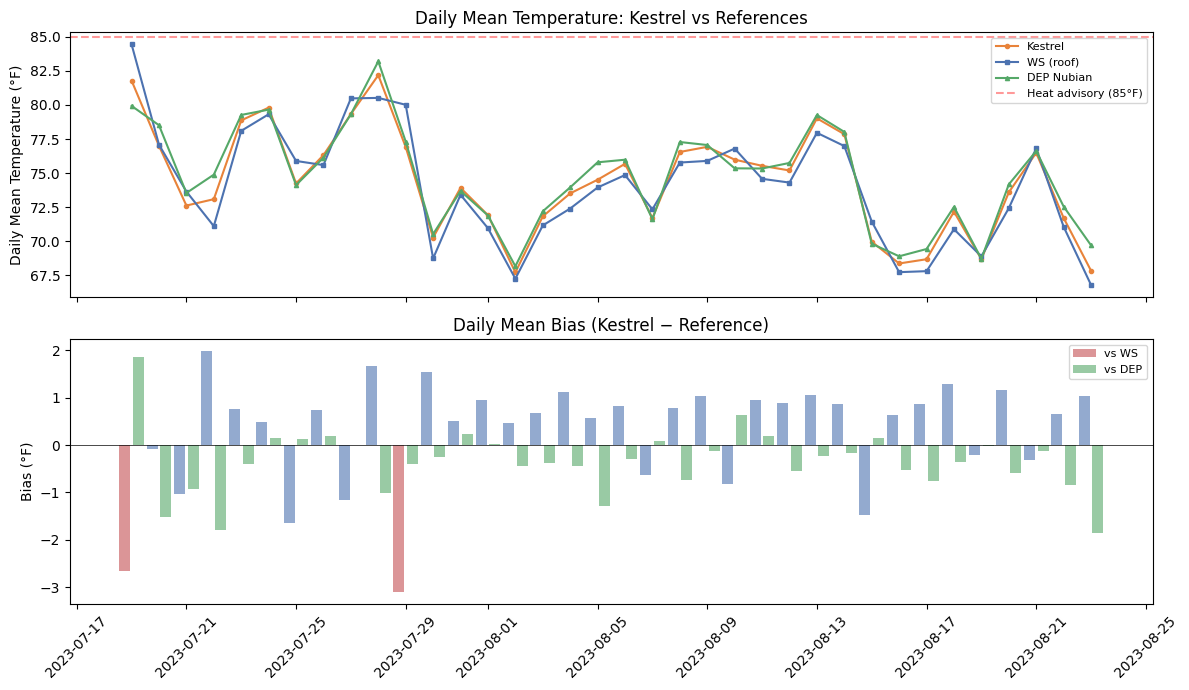

In [17]:
# Daily temperature time series
daily = sub.groupby("date_only").agg(
    mean_kes=(kes_temp, "mean"), mean_ws=(ws_temp, "mean"), mean_dep=(dep_temp, "mean"),
    bias_ws=("kes_ws_diff", "mean"), bias_dep=("kes_dep_diff", "mean"),
    max_kes=(kes_temp, "max"),
).reset_index()
daily["date_only"] = pd.to_datetime(daily["date_only"])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Panel 1: Daily mean temperatures
axes[0].plot(daily["date_only"], daily["mean_kes"], "-o", markersize=3, color="#E8833A", label="Kestrel")
axes[0].plot(daily["date_only"], daily["mean_ws"], "-s", markersize=3, color="#4C72B0", label="WS (roof)")
axes[0].plot(daily["date_only"], daily["mean_dep"], "-^", markersize=3, color="#55A868", label="DEP Nubian")
axes[0].axhline(85, color="red", linestyle="--", alpha=0.4, label="Heat advisory (85°F)")
axes[0].set_ylabel("Daily Mean Temperature (°F)")
axes[0].set_title("Daily Mean Temperature: Kestrel vs References")
axes[0].legend(fontsize=8)

# Panel 2: Daily bias
colors_ws = ["#C44E52" if abs(b) > 2 else "#4C72B0" for b in daily["bias_ws"]]
axes[1].bar(daily["date_only"] - pd.Timedelta(hours=6), daily["bias_ws"],
            width=0.4, color=colors_ws, alpha=0.6, label="vs WS")
axes[1].bar(daily["date_only"] + pd.Timedelta(hours=6), daily["bias_dep"],
            width=0.4, color="#55A868", alpha=0.6, label="vs DEP")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("Bias (°F)")
axes[1].set_title("Daily Mean Bias (Kestrel − Reference)")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(FIG_DIR / "q2_daily_timeseries.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

The daily time series confirms:
- **All three sources track the same multi-day temperature waves** — the broad synoptic pattern is captured by all
- **Daily mean WS bias is modest** (±2°F most days) because the inverted diurnal cycle partially cancels out when averaged. The WS is *not* wrong on average — it's wrong at every individual time point.
- **DEP bias is remarkably stable** day-to-day, rarely exceeding ±1°F in the daily mean

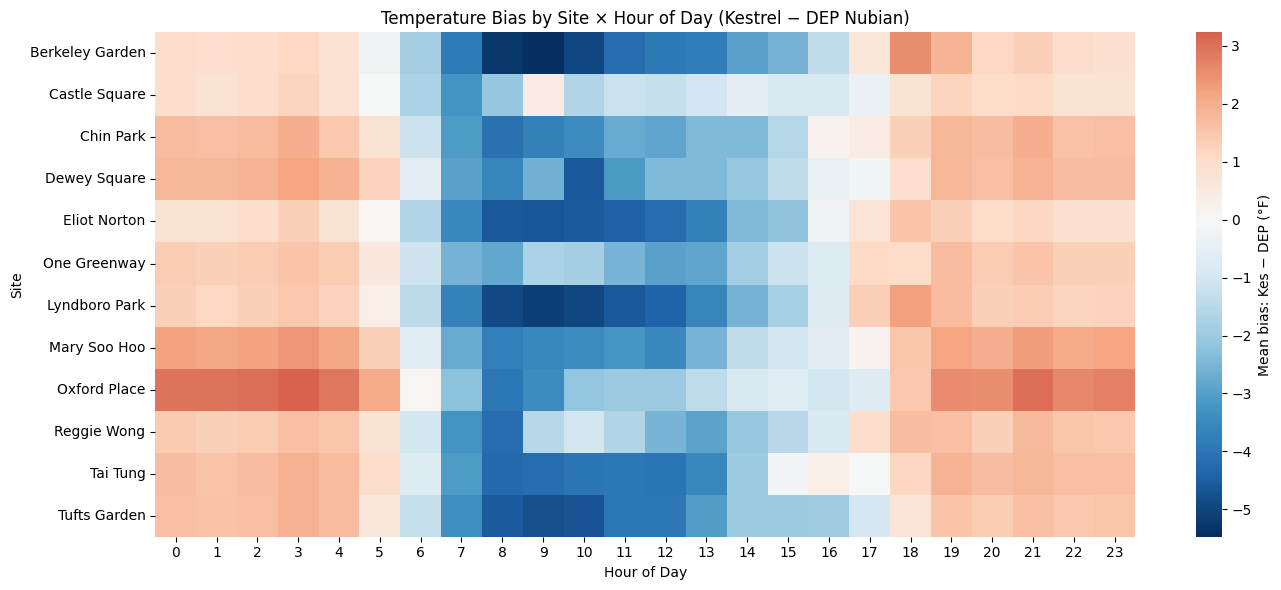

In [18]:
# Hourly bias heatmap: site × hour (vs DEP)
site_hour = sub.groupby(["site_id", "hour"])["kes_dep_diff"].mean().unstack()
site_hour = site_hour.reindex(sites_sorted)
site_hour.index = [SITE_NAMES[s] for s in site_hour.index]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(site_hour, cmap="RdBu_r", center=0, annot=False,
            xticklabels=True, yticklabels=True,
            cbar_kws={"label": "Mean bias: Kes − DEP (°F)"}, ax=ax)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Site")
ax.set_title("Temperature Bias by Site × Hour of Day (Kestrel − DEP Nubian)")
plt.tight_layout()
fig.savefig(FIG_DIR / "q2_site_hour_heatmap.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

The site × hour heatmap reveals that:
- **All 12 sites share the same diurnal bias pattern**: positive (red) during late morning/midday, negative (blue) at night — the ground-level sites warm faster than DEP Nubian in the morning and cool faster in the evening
- **Site-level differences are consistent across hours**: Oxford Place is consistently warmer (more red) while Eliot Norton/Berkeley are consistently cooler (more blue)
- **The pattern is driven by the open-space environment**: Kestrel sensors in open spaces experience direct solar radiation during the day and radiative cooling at night, while the DEP station may be partially shielded

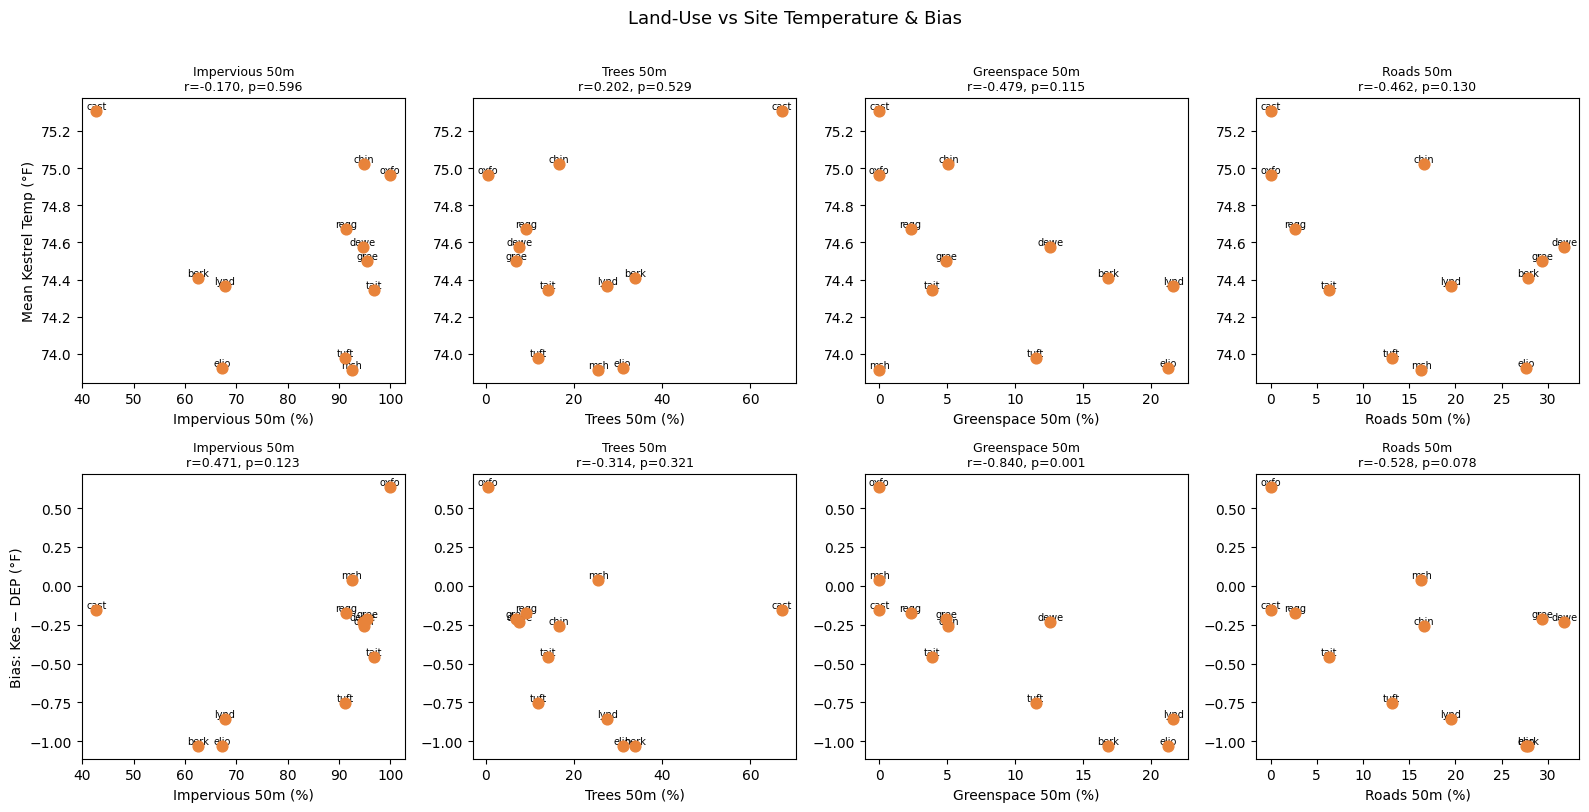

In [19]:
# Land-use associations with temperature
lu_cols = {
    "Impervious 50m": "Impervious_Area_Percent_50m",
    "Trees 50m": "Trees_Area_Percent_50m",
    "Greenspace 50m": "Greenspace_Area_Percent_50m",
    "Roads 50m": "Roads_Area_Percent_50m",
}

site_lu = df.groupby("site_id")[list(lu_cols.values())].first()
site_lu["mean_temp"] = sub.groupby("site_id")[kes_temp].mean()
site_lu["bias_dep"] = sub.groupby("site_id")["kes_dep_diff"].mean()
site_lu = site_lu.dropna(subset=["mean_temp"])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, (y_col, y_label) in enumerate([("mean_temp", "Mean Kestrel Temp (°F)"),
                                          ("bias_dep", "Bias: Kes − DEP (°F)")]):
    for col_idx, (label, lu_col) in enumerate(lu_cols.items()):
        ax = axes[row, col_idx]
        x = site_lu[lu_col] * 100
        y = site_lu[y_col]
        ax.scatter(x, y, s=60, color="#E8833A", zorder=5)
        for sid in site_lu.index:
            ax.annotate(sid[:4], (site_lu.loc[sid, lu_col]*100, site_lu.loc[sid, y_col]),
                        fontsize=7, ha="center", va="bottom")
        r, p = stats.pearsonr(x, y)
        ax.set_title(f"{label}\nr={r:.3f}, p={p:.3f}", fontsize=9)
        ax.set_xlabel(f"{label} (%)")
        if col_idx == 0:
            ax.set_ylabel(y_label)

plt.suptitle("Land-Use vs Site Temperature & Bias", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "q2_landuse_temp.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

Land-use analysis reveals a striking finding:
- **Greenspace vs DEP bias: r = −0.84, p = 0.001** — this is the strongest land-use association in the entire Q2 analysis. Sites with more greenspace within 50m read significantly cooler than the DEP reference. This is a classic green infrastructure cooling effect.
- **Impervious surface vs bias: r = +0.47** (not significant at n=12, but directionally correct) — more pavement → warmer Kestrel readings vs DEP
- This motivates the environmental justice question: neighborhoods with less green space not only have fewer cool refuges but also have temperatures that reference stations underestimate

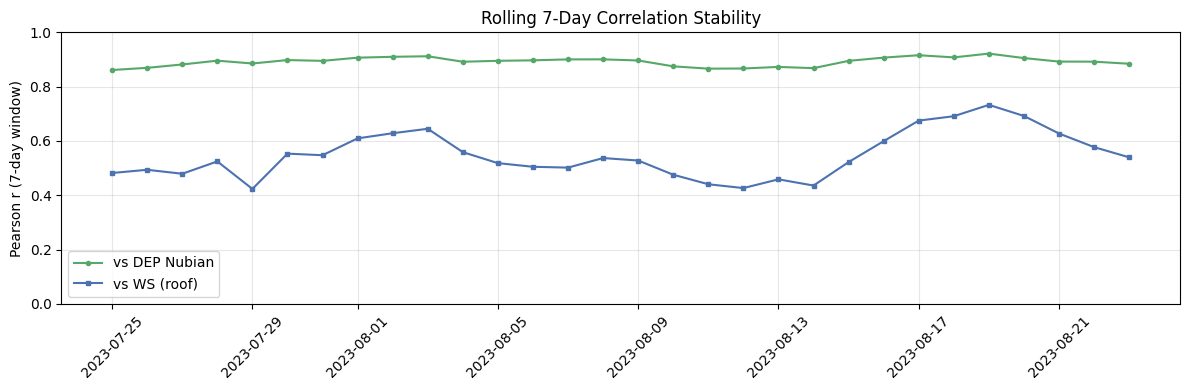

DEP r range: 0.8612 – 0.9217
WS r range: 0.4232 – 0.7328


In [20]:
# Rolling 7-day correlation stability (DEP comparison)
sub_sorted = sub.sort_values("datetime").copy()
sub_sorted["date"] = sub_sorted["datetime"].dt.date

roll_stats = []
dates = sorted(sub_sorted["date"].unique())
for i in range(6, len(dates)):
    window_dates = dates[i-6:i+1]
    w = sub_sorted[sub_sorted["date"].isin(window_dates)]
    if len(w) > 50:
        r_d, _ = stats.pearsonr(w[kes_temp], w[dep_temp])
        r_w, _ = stats.pearsonr(w[kes_temp], w[ws_temp])
        roll_stats.append({"date": dates[i], "r_dep": r_d, "r_ws": r_w})

roll_df = pd.DataFrame(roll_stats)
roll_df["date"] = pd.to_datetime(roll_df["date"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(roll_df["date"], roll_df["r_dep"], "-o", markersize=3, color="#55A868", label="vs DEP Nubian")
ax.plot(roll_df["date"], roll_df["r_ws"], "-s", markersize=3, color="#4C72B0", label="vs WS (roof)")
ax.set_ylabel("Pearson r (7-day window)")
ax.set_title("Rolling 7-Day Correlation Stability")
ax.legend()
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "q2_rolling_stability.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

print(f"DEP r range: {roll_df['r_dep'].min():.4f} – {roll_df['r_dep'].max():.4f}")
print(f"WS r range: {roll_df['r_ws'].min():.4f} – {roll_df['r_ws'].max():.4f}")

Temporal stability analysis confirms that:
- **DEP correlation is consistently high** (r > 0.87) throughout the study — no sensor drift or degradation
- **WS correlation is consistently poor** — the low r is not due to occasional bad days but a persistent structural issue (the rooftop thermal mass)
- The gap between the two reference comparisons is stable, confirming this is a systematic measurement characteristic, not weather-dependent

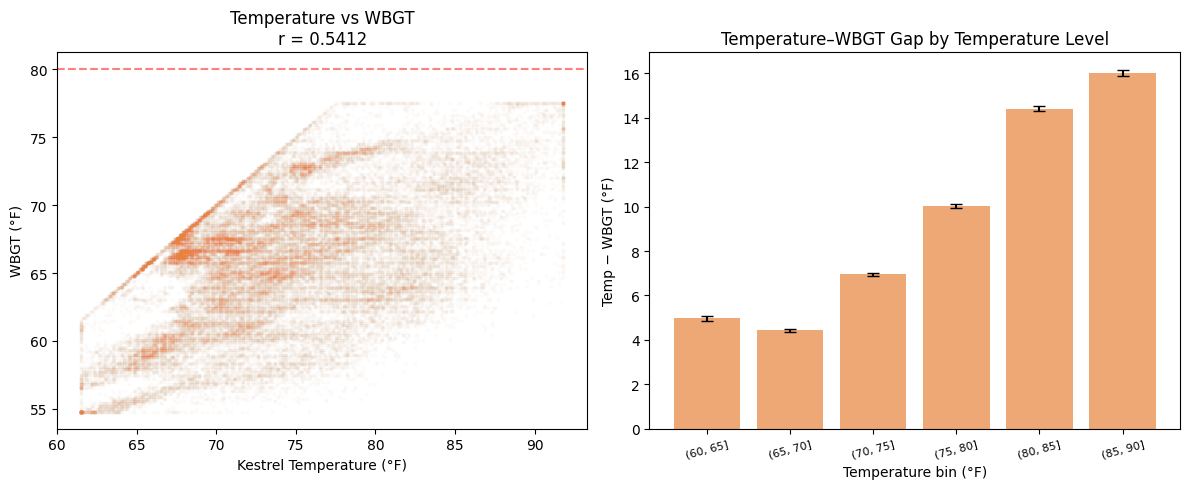

Mean temp–WBGT gap: 8.62°F
Max WBGT: 77.5°F (never reached 80°F OSHA caution)


In [21]:
# Temperature vs WBGT relationship
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: Temp vs WBGT
m_wbgt = sub[wbgt_col].notna()
axes[0].scatter(sub.loc[m_wbgt, kes_temp], sub.loc[m_wbgt, wbgt_col],
                alpha=0.02, s=3, color="#E8833A")
r_tw, _ = stats.pearsonr(sub.loc[m_wbgt, kes_temp], sub.loc[m_wbgt, wbgt_col])
axes[0].set_xlabel("Kestrel Temperature (°F)")
axes[0].set_ylabel("WBGT (°F)")
axes[0].set_title(f"Temperature vs WBGT\nr = {r_tw:.4f}")
axes[0].axhline(80, color="red", linestyle="--", alpha=0.5, label="OSHA Caution (80°F)")

# Difference by temperature bin
temp_b = pd.cut(sub.loc[m_wbgt, kes_temp], bins=np.arange(60, 95, 5))
diff_tw = sub.loc[m_wbgt, kes_temp] - sub.loc[m_wbgt, wbgt_col]
tw_stats = pd.DataFrame({"bin": temp_b, "diff": diff_tw}).groupby("bin")["diff"].agg(["mean", "std", "count"])
axes[1].bar(range(len(tw_stats)), tw_stats["mean"], yerr=1.96*tw_stats["std"]/np.sqrt(tw_stats["count"]),
            color="#E8833A", alpha=0.7, capsize=4)
axes[1].set_xticks(range(len(tw_stats)))
axes[1].set_xticklabels([str(b) for b in tw_stats.index], rotation=15, fontsize=8)
axes[1].set_xlabel("Temperature bin (°F)")
axes[1].set_ylabel("Temp − WBGT (°F)")
axes[1].set_title("Temperature–WBGT Gap by Temperature Level")

plt.tight_layout()
fig.savefig(FIG_DIR / "q2_temp_vs_wbgt.png", dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

print(f"Mean temp–WBGT gap: {diff_tw.mean():.2f}°F")
print(f"Max WBGT: {sub[wbgt_col].max():.1f}°F (never reached 80°F OSHA caution)")

Temperature and WBGT are only moderately correlated (r ≈ 0.54) because WBGT incorporates humidity and solar radiation. The temperature-WBGT gap varies by temperature level:
- At lower temperatures (<70°F), the gap is small (~5°F)
- At high temperatures (>85°F), the gap is larger (~10°F+) because dry-bulb temperature rises faster than wet-bulb
- **WBGT never reached the OSHA caution threshold (80°F)** during this study period (max = 77.5°F), even though air temperature exceeded 90°F on multiple occasions — a critical public health nuance

---
## Synthesis & Conclusions

### Key Findings

1. **DEP Nubian is the gold-standard reference**: Kestrel–DEP correlation is strong (r = 0.90) with small bias (−0.37°F) and reasonable RMSE (3.1°F). This relationship is stable across all 12 sites (r = 0.877–0.929) and throughout the study period.

2. **The WS at 35 Kneeland St is unsuitable for ground-level temperature monitoring**: The rooftop thermal mass creates a **4-hour phase lag** in the diurnal temperature cycle. This inverted cycle produces a 13.5°F bias swing over each day (−4.8°F at night to +8.8°F at midday). The zero-lag correlation (r = 0.60) is misleadingly low; lag-corrected r = 0.998 shows the sensor itself is not faulty — it's simply measuring a different thermal environment.

3. **Microclimate matters — 1.4°F urban heat island effect**: Castle Square is consistently 1.4°F warmer than Mary Soo Hoo, a small but persistent difference driven by local factors (impervious surface, shade, airflow). Reference monitors cannot capture this granularity.

4. **Greenspace is the strongest predictor of temperature bias**: The correlation between greenspace percentage (50m buffer) and Kestrel–DEP bias is r = −0.84 (p = 0.001). More green space → cooler Kestrel readings relative to reference. This has environmental justice implications: the official DEP monitor may *underestimate* cooling benefits of green infrastructure.

5. **WBGT provides different information than temperature alone**: Despite air temperatures exceeding 90°F, WBGT never reached the OSHA caution threshold (80°F). Temperature alone overstates heat stress risk when humidity is moderate.

### Limitations

- Single summer study period (Jul–Aug 2023) — seasonal generalization limited
- WS rooftop placement is a known limitation; findings should prompt station relocation review
- With 12 sites, land-use analyses are exploratory (low power for detecting small effects)
- No direct solar radiation measurements — can't fully separate radiative heating from convective effects

### Implications for Community Monitoring

- **For researchers**: Use DEP Nubian as the reference. The WS data can be used for daily averages (where the bias partially cancels) but never for time-resolved analyses.
- **For city planners**: Rooftop weather stations systematically misrepresent ground-level thermal conditions. Investment in ground-level monitoring (like HEROS) is essential for heat equity assessments.
- **For community members**: The official weather station temperature may not reflect what you experience in parks and open spaces. On hot afternoons, ground-level temperatures can be 5–8°F higher than what the rooftop station reports.